# GPN accession-embedding UMAP explorer

UMAP of the per-accession **GPN-brassicales chr4** embeddings under increasing
levels of processing.

The window embeddings are dominated (~99.97% of variance) by *which window* —
shared reference-sequence structure identical across accessions — with only a
tiny (~1e-4) per-accession *which-allele* component. So the interesting signal
only surfaces once we strip the shared part. The processing ladder:

1. **mean-pool (raw)** — `embedding_bag(mean)` of the window embeddings.
2. **z-scored** — per-dim standardize (the transform the ridge kernel used).
3. **z-scored + PCA50** — standard UMAP preprocessing.
4. **window-centered** — subtract each window's across-accession mean *before*
   pooling → keeps only the per-accession deviation (the "which-allele" signal).
5. **window-centered + z-scored**
6. **window-centered + z-scored + PCA50**

Each panel is colored by a phenotype (FT10) and, in a second figure, by
**genotype PC1** (chr4 GRM) to see whether the embedding recapitulates
population structure / kinship.

In [1]:
import os, time
import numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
import umap

SCRATCH = os.environ.get("SVAR_SCRATCH", "/home/andrew/svar_scratch")
CACHE = f"{SCRATCH}/caches/arabidopsis/gpn_chr4_hw256.ckpt.pt"
SPLIT = "/home/andrew/svar/splits/arabidopsis_seed42.pt"
GENO_PCA = f"{SCRATCH}/arab/geno_chr4_pca1000.npz"   # chr4 GRM eigvectors
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

/home/andrew/anaconda3/envs/svar/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda:0


## 1. Load cache, split targets, and genotype PCs

In [2]:
t0 = time.time()
c = torch.load(CACHE, map_location="cpu", weights_only=False)
cache = c["cache"].float()                 # (n_unique_windows, 512)
sfi = c["sample_fp_index"]                  # (n_cache_samples, n_windows) long
cache_ids = list(c["sample_ids"])           # 1135 VCF-order accessions
print(f"cache {tuple(cache.shape)}  sfi {tuple(sfi.shape)}  ({len(cache_ids)} accessions) in {time.time()-t0:.1f}s")

sp = torch.load(SPLIT, map_location="cpu", weights_only=False)
sids = list(sp["sample_ids"])               # 1041 phenotyped accessions
tcol = {t: i for i, t in enumerate(sp["trait_cols"])}
Y = sp["targets"].numpy()
traits = {"FT10": Y[:, tcol["261"]], "CL": Y[:, tcol["705"]], "RBN": Y[:, tcol["706"]]}

pcz = np.load(GENO_PCA, allow_pickle=True)
pc_ids = list(pcz["sample_ids"])
pc_pos = {s: i for i, s in enumerate(pc_ids)}
geno_pc1 = pcz["Z"][[pc_pos[s] for s in sids], 0]     # chr4 genotype PC1, aligned to sids
print("aligned:", len(sids), "accessions | traits:", list(traits))

cache (2087032, 512)  sfi (1135, 47696)  (1135 accessions) in 4.2s
aligned: 1041 accessions | traits: ['FT10', 'CL', 'RBN']


## 2. Pool windows → per-accession embeddings (raw mean & window-centered)

In [3]:
# GPU-chunked over the 47,696 window positions. cache lives on GPU (~4 GB);
# each chunk gathers (n_acc, chunk, 512). window-centering subtracts each
# window's across-accession mean before summing.
cache_gpu = cache.to(DEVICE)
n, W = sfi.shape
CHUNK = 512
S_mean = torch.zeros(n, cache.shape[1])
S_wc = torch.zeros(n, cache.shape[1])
t0 = time.time()
for w0 in range(0, W, CHUNK):
    idx = sfi[:, w0:w0 + CHUNK].to(DEVICE)      # (n, cw)
    g = cache_gpu[idx]                          # (n, cw, 512)
    S_mean += g.sum(1).cpu()
    g = g - g.mean(0, keepdim=True)             # center across accessions, per window
    S_wc += g.sum(1).cpu()
E_mean = (S_mean / W).numpy()
E_wc = (S_wc / W).numpy()
del cache_gpu
torch.cuda.empty_cache()
print(f"pooled in {time.time()-t0:.1f}s  E_mean {E_mean.shape}  E_wc {E_wc.shape}")

# restrict cache-row order (1135) -> phenotyped accessions (sids, 1041)
cpos = {s: i for i, s in enumerate(cache_ids)}
rows = [cpos[s] for s in sids]
E_mean = E_mean[rows]
E_wc = E_wc[rows]
print("restricted to", E_mean.shape[0], "accessions")

pooled in 1.2s  E_mean (1135, 512)  E_wc (1135, 512)
restricted to 1041 accessions


## 3. Processing ladder

In [4]:
from sklearn.decomposition import PCA

def zscore(X):
    mu = X.mean(0); sd = X.std(0); sd[sd == 0] = 1.0
    return (X - mu) / sd

def pca50(X):
    return PCA(n_components=50, random_state=0).fit_transform(X)

levels = {
    "1. mean-pool (raw)":                 E_mean,
    "2. mean-pool z-scored":              zscore(E_mean),
    "3. mean-pool z-scored + PCA50":      pca50(zscore(E_mean)),
    "4. window-centered (raw)":           E_wc,
    "5. window-centered z-scored":        zscore(E_wc),
    "6. window-centered z-scored + PCA50": pca50(zscore(E_wc)),
}
for k, v in levels.items():
    print(f"{k:38s} {v.shape}")

1. mean-pool (raw)                     (1041, 512)
2. mean-pool z-scored                  (1041, 512)
3. mean-pool z-scored + PCA50          (1041, 50)
4. window-centered (raw)               (1041, 512)
5. window-centered z-scored            (1041, 512)
6. window-centered z-scored + PCA50    (1041, 50)


## 4. UMAP each level (reused across colorings)

In [5]:
def run_umap(X):
    return umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean",
                     random_state=42).fit_transform(X)

t0 = time.time()
umaps = {}
for name, X in levels.items():
    umaps[name] = run_umap(X)
    print(f"  umap {name:38s} done ({time.time()-t0:.1f}s elapsed)")

/home/andrew/anaconda3/envs/svar/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  umap 1. mean-pool (raw)                     done (7.8s elapsed)


/home/andrew/anaconda3/envs/svar/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  umap 2. mean-pool z-scored                  done (9.5s elapsed)


/home/andrew/anaconda3/envs/svar/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

  umap 4. window-centered (raw)               done (12.9s elapsed)


/home/andrew/anaconda3/envs/svar/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  umap 5. window-centered z-scored            done (14.6s elapsed)


/home/andrew/anaconda3/envs/svar/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  umap 6. window-centered z-scored + PCA50    done (16.3s elapsed)


## 5. Colored by FT10 (flowering time)

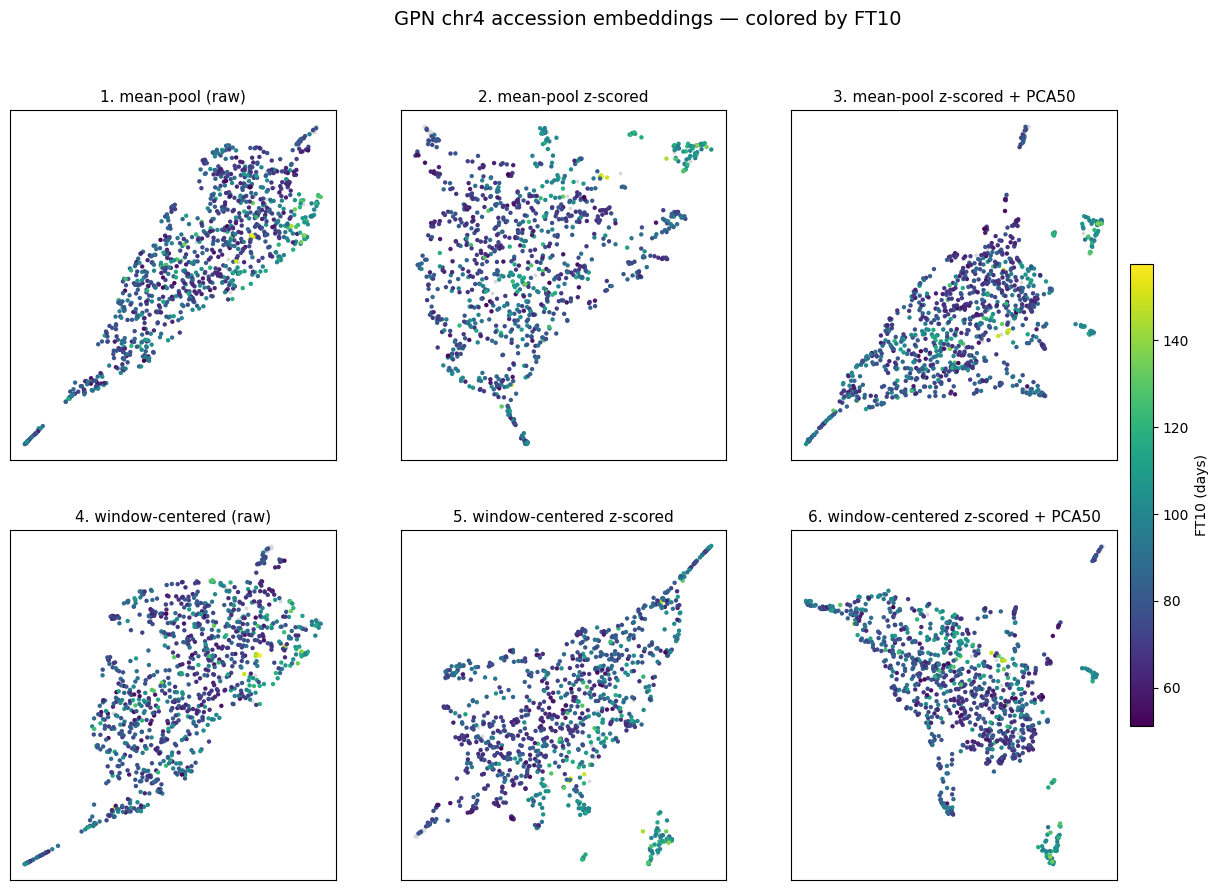

In [6]:
def plot_grid(umaps, color, title, cmap="viridis", cbar_label=""):
    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    color = np.asarray(color, dtype=float)
    nan = np.isnan(color)
    for ax, (name, xy) in zip(axes.ravel(), umaps.items()):
        if nan.any():
            ax.scatter(xy[nan, 0], xy[nan, 1], c="0.85", s=8, linewidths=0)
        sc = ax.scatter(xy[~nan, 0], xy[~nan, 1], c=color[~nan], cmap=cmap,
                        s=10, linewidths=0)
        ax.set_title(name, fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(sc, ax=axes, shrink=0.6, label=cbar_label, pad=0.01)
    fig.suptitle(title, fontsize=14)
    return fig

plot_grid(umaps, traits["FT10"], "GPN chr4 accession embeddings — colored by FT10",
          cmap="viridis", cbar_label="FT10 (days)")
plt.show()

## 6. Colored by genotype PC1 (chr4 kinship / population structure)

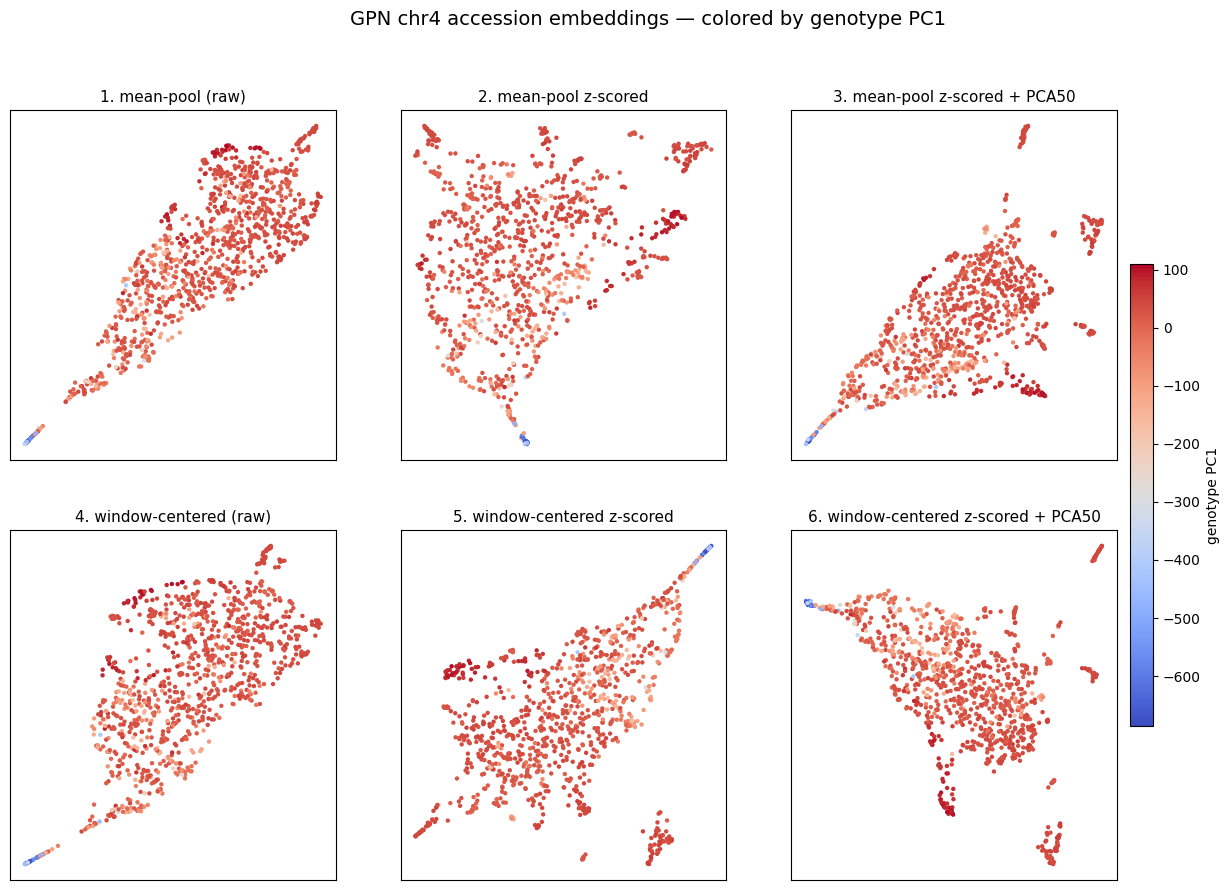

In [7]:
plot_grid(umaps, geno_pc1, "GPN chr4 accession embeddings — colored by genotype PC1",
          cmap="coolwarm", cbar_label="genotype PC1")
plt.show()

## 7. (optional) recolor by another trait
Change the trait key to `CL` or `RBN`.

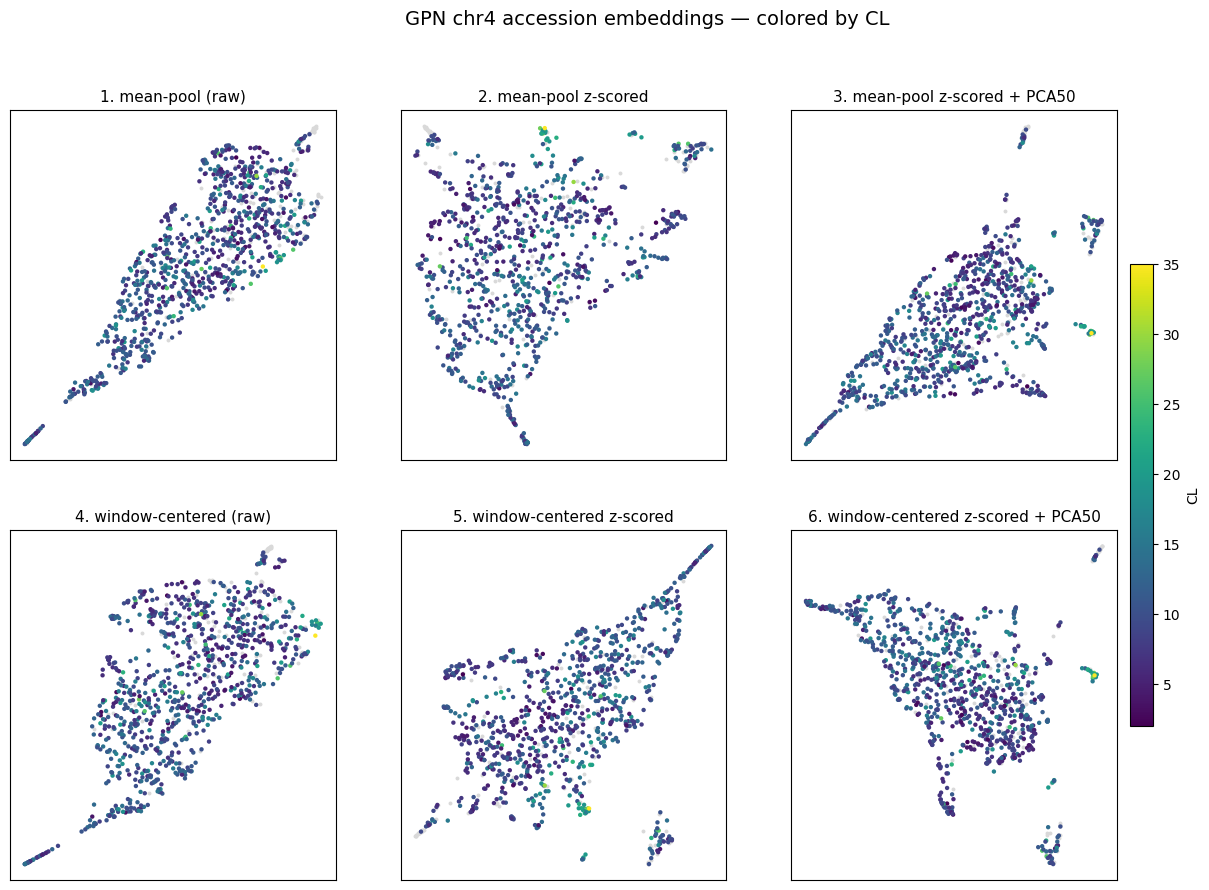

In [8]:
plot_grid(umaps, traits["CL"], "GPN chr4 accession embeddings — colored by CL",
          cmap="viridis", cbar_label="CL")
plt.show()